# Notebook 6
# Case Study Performance Benchmark

This notebook measures the computational benefit of activating the FEM pendulum only near contact.
It compares a full-FEM closed-loop run against a switched run whose plant holds **only the FEM and
the FMU pendulum**, handing the horizon between them at an event-localized angle boundary.

The plant is a two-model `MultiComponent` defined below rather than `MasterPendulum`.
`MasterPendulum` always constructs the OpenSim backend as well, and paying that construction and
initialization cost in a timing benchmark charges the switched case for a model its region policy
never selects.

A launch-time gate on the region key keeps the FMU active while the pendulum swings away from the
wall, where the FEM model would otherwise run without being able to contact anything. The gate and
its consequences are described under *Time-Gated Region Key*.

Two things are measured per case. The median wall time over repeated fresh runs is the headline
number, and every model call is attributed to the algorithm phase that issued it, so accepted work
is separated from work that is computed and then rolled back.

`07_casestudy_performance_nocontact.ipynb` is the contact-free sibling of this notebook and shares
that instrumentation. Both notebooks run `HybridAlgorithm` on both of their cases, so the plain
wall-time ratio is a like-for-like comparison in each, and it is the number to quote. Here the
full-FEM plant is an event source because `wall_hit` makes it one. Notebook 7 has no contact and
so no indicator of its own, and gives its baseline a constant, never-crossing indicator for the
sole purpose of making both cases pay the same detection overhead.

## Imports and Repository Setup


In [1]:
from pathlib import Path
import sys

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent

sys.path.insert(0, str(_repo))
# plot_setup.py lives next to this notebook, which is not the working directory
# when the notebook is executed headlessly (nbmake, papermill).
sys.path.insert(0, str(_repo / "notebooks"))

# Confirm resolution without printing the absolute path, which would be
# committed into the published outputs (issues.md HARD-06).
print(f"repository root resolved: {_repo.name}")

repository root resolved: SystemSimulation


In [2]:
from dataclasses import dataclass, field
from functools import wraps
from time import perf_counter_ns
import gc
import platform

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

from plot_setup import FULL_WIDTH
from plot_setup import set_professional_style

plt = set_professional_style(latex=True)

from syssimx_examples.controlled_pendulum.components import FEMPendulum, FMUPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config

from syssimx import FMUComponent, System, Connection, EventConnection
from syssimx.core.multi_comp import MultiComponent
from syssimx.system.algorithms import GaussSeidelAlgorithm, HybridAlgorithm

from OMPython import ModelicaSystem

## Benchmark Configuration

Use `N_WARMUP = 1`, `N_REPEATS = 5` for a citable result. For a smoke test set them to `0` and `1`.

`FEM_SWITCH_THRESHOLD_RAD` is the region boundary on `abs(theta)`. The wall sits at `theta = 0`, so
the **inner** region is the contact-relevant one and carries the FEM model, while the FMU model runs
the outer region away from the wall.

> **Absolute timings are environment-sensitive; report the ratio.** The same benchmark has measured
> 468 s, 532 s, and 610 s for the full-FEM case on this machine depending on the interpreter and on
> whether the run was warmed. Roughly 15 % of that spread is Python 3.13 versus 3.12 alone. Compare
> only runs that share `BENCHMARK_ENV`, and never compare a single cold run against a warmed median.
> The ratio is far more stable than either absolute number, so the summary reports the median of the
> **per-repetition ratios** next to the ratio of the medians. The drift check between them guards the
> one case a median cannot: a series that climbs monotonically across repetitions.

> **This notebook is expensive.** With `with_contact = True` the FEM mesh is refined, and one FEM
> solve costs on the order of seconds rather than the ~0.1 s of the contact-free notebook 7. The
> hybrid algorithm additionally solves every macro step twice - once as a trial step in
> `_detect_crossings` and once for real - so the full-FEM case is roughly `2 * (T_END / MACRO_DT)`
> FEM solves. Budget accordingly before raising `N_REPEATS`, and prefer `N_REPEATS = 3` when the
> paired ratio is all that is needed.

In [3]:
T0 = 0.0
T_END = 0.4
MACRO_DT = 1e-3
FEM_INTERNAL_DT = 1e-3
CONTACT_STIFFNESS = 2e9

# Shape of the SetPoint FMU wired into the loop below. The event tolerance is
# derived from it, so it has to match that export. Notebook 7 derives the same
# quantity from the same FMU; the two must not disagree.
THETA_AMPLITUDE_DEG = 20.0
SETPOINT_FREQ_HZ = 3.0

# Region policy on abs(theta). FEM holds the inner region, which contains the
# wall at theta = 0; the FMU holds the outer region.
FEM_SWITCH_THRESHOLD_RAD = 0.075
FEM_SWITCH_BAND_RAD = 0.005
REGION_MODES = ("FEM", "FMU")

# Launch gate. theta starts at 0, which is inside the FEM region, so an ungated
# region map runs the deformable model while the pendulum accelerates away from
# the wall. The gate suppresses that window; it only has to last until
# abs(theta) has left the FEM region on its own, at about 24 ms.
GATE_T_OPEN_S = 0.03
GATE_OFFSET_RAD = 0.35

FMU_SOLVER = "cvode"

N_WARMUP = 1
N_REPEATS = 5

OUT_DIR = _repo / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

BENCHMARK_ENV = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "processor": platform.processor(),
    "n_warmup": N_WARMUP,
    "n_repeats": N_REPEATS,
    "t_end": T_END,
    "macro_dt": MACRO_DT,
    "fem_internal_dt": FEM_INTERNAL_DT,
    "contact_stiffness": CONTACT_STIFFNESS,
    "fem_switch_threshold_rad": FEM_SWITCH_THRESHOLD_RAD,
    "fem_switch_band_rad": FEM_SWITCH_BAND_RAD,
    "gate_t_open_s": GATE_T_OPEN_S,
    "gate_offset_rad": GATE_OFFSET_RAD,
    "theta_amplitude_deg": THETA_AMPLITUDE_DEG,
    "setpoint_freq_hz": SETPOINT_FREQ_HZ,
    "fmu_solver": FMU_SOLVER,
}

BENCHMARK_ENV

{'python': '3.13.5',
 'platform': 'Windows-11-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 165 Stepping 2, GenuineIntel',
 'n_warmup': 1,
 'n_repeats': 5,
 't_end': 0.4,
 'macro_dt': 0.001,
 'fem_internal_dt': 0.001,
 'contact_stiffness': 2000000000.0,
 'fem_switch_threshold_rad': 0.075,
 'fem_switch_band_rad': 0.005,
 'gate_t_open_s': 0.03,
 'gate_offset_rad': 0.35,
 'theta_amplitude_deg': 20.0,
 'setpoint_freq_hz': 3.0,
 'fmu_solver': 'cvode'}

## Discover FMUs


In [4]:
PLATFORM = sys.platform
DEMO_DIR = _repo / "demos" / "ControlledPendulum"
FMU_DIR = DEMO_DIR / "artifacts" / "fmus" / PLATFORM

fmu_paths = {}
for subdir in FMU_DIR.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

sorted(fmu_paths.keys())

['Actuators', 'Controllers', 'Plants', 'Sensors', 'Trajectories']

## Shared Helpers


In [5]:
def scalar_value(value):
    if isinstance(value, dict):
        value = value.get("value", np.nan)
    if hasattr(value, "magnitude"):
        value = value.magnitude
    return float(value)


def make_fem_parameters():
    init_params = config.InitialConditionParameters()
    init_params.angular_position_deg = 0.0

    sim_params = config.SimulationParameters()
    sim_params.tau = FEM_INTERNAL_DT
    sim_params.t_end = T_END
    sim_params.with_contact = True
    sim_params.use_gravity = True

    anim_params = config.AnimationParameters()
    anim_params.animate = False

    return {
        "init_params": init_params,
        "sim_params": sim_params,
        "anim_params": anim_params,
    }


PLANT_NAME = "Pendulum"
PLANT_DIRECT_FEEDTHROUGH = {
    "theta": set(),
    "omega": set(),
    "alpha": {"tau"},
}


def declare_plant_feedthrough(component):
    """Declare plant feedthrough before System.initialize().

    System.initialize() needs feedthrough metadata before it initializes
    pure-Python components. The FEM plant cannot be safely perturbed before
    its torque boundary has been assembled, so the known map is declared here.
    """
    component.direct_feedthrough = {
        out_name: set(inputs)
        for out_name, inputs in PLANT_DIRECT_FEEDTHROUGH.items()
    }
    return component


def wall_contact_indicator(comp) -> float:
    theta = scalar_value(comp.get_outputs()["theta"])
    theta_wall = 0.0
    return theta - theta_wall


def absolute_theta(comp) -> float:
    """Absolute deflection in radians, read off the wrapper.

    Evaluated against the `MultiComponent` rather than a sub-model, so it reads
    the unified `theta` output regardless of which model is currently active.
    """
    value = comp.outputs["theta"].get()
    if value is None:
        return 0.0
    return abs(float(getattr(value, "magnitude", value)))


class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths["Controllers"]["PIDControllerReset_euler"]
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0.0)
        self.set_inputs({"resetI": False})

## Plant: FEM + FMU only

The switched plant is a local `MultiComponent` holding exactly the two models the region policy can
select. `MasterPendulum` would work as well, but it constructs and initializes the OpenSim backend
unconditionally, which a benchmark would then charge to the switched case for no return.

Two pieces of `MasterPendulum` are kept because they are not optional:

- **FEM is initialized first.** It derives mass, inertia, and equivalent length from its mesh, and
  the FMU has to be parameterised from those values or the two models describe different pendulums.
- **`_adapt_state` renames the state.** The FMU takes initial conditions (`theta_start`,
  `omega_start`), while the FEM uses the running state (`theta`, `omega`).

Contact needs nothing from the wrapper. The FMU pendulum carries no contact model at all: the wall
is a `wall_hit` event on the plant that dispatches `omega_invert`, an event input both backends
declare, so the bounce is applied to whichever model is active.

In [6]:
class ContactSwitchingPendulum(MultiComponent):
    """FEM/FMU pendulum pair with event-localized region switching and wall contact."""

    def __init__(self, name=PLANT_NAME, initial_mode="FEM", fmu_solver=FMU_SOLVER):
        self.fem = FEMPendulum(name="FEM_Pendulum")
        self.fmu = FMUPendulum(name="FMU_Pendulum", solver=fmu_solver)

        super().__init__(
            name=name,
            models={"FEM": self.fem, "FMU": self.fmu},
            initial_mode=initial_mode,
            group="Plant",
        )

        self._unify_ports()
        self._initialize_ports_from_specs()
        self.parameters.update({
            "FEM": self.fem.get_parameters(),
            "FMU": self.fmu.get_parameters(),
        })

    def _initialize_component(self, t0):
        # FEM first: its mesh determines the physical parameters the FMU needs.
        self.fem.set_parameters(**self.parameters.get("FEM", {}))
        self.fem.initialize(t0)
        self._sync_fmu_from_fem()
        self.fmu.initialize(t0)
        self.direct_feedthrough = self.active_comp.direct_feedthrough

    def _sync_fmu_from_fem(self):
        self.fmu.set_parameters(
            theta_start=np.deg2rad(self.fem.init_params.angular_position_deg),
            omega_start=self.fem.init_params.angular_velocity,
            m=self.fem.mass,
            L=self.fem._equivalent_length,
            J=self.fem.inertia,
            g=9.81 if self.fem._use_gravity else 0.0,
        )

    def _adapt_state(self, state, target_mode):
        if target_mode == "FMU":
            return {
                "theta_start": state["theta"],
                "omega_start": state["omega"],
                "tau": state["tau"],
            }
        return state

## Time-Gated Region Key

The region key is `abs(theta)` and the wall sits at `theta = 0`, so the pendulum starts *inside* the
FEM region. Initialization reconciles to FEM and the deformable model runs through the launch, where
the pendulum accelerates **away** from the wall and cannot contact anything. Measured on this system
that window lasts until `abs(theta)` clears the upper threshold at about 24 ms - roughly 48 FEM
solves at half a second each, for no fidelity at all.

`TimeGatedRegionKey` adds a decaying offset to the key. The offset starts at `GATE_OFFSET_RAD`,
above the boundary's upper threshold, and ramps linearly to zero at `GATE_T_OPEN_S`. After that the
key *is* `abs(theta)` and the ordinary angle policy governs unchanged, so the switch into FEM is
still driven by proximity to the wall and not by a schedule.

> **The gate reads the sub-model's clock, not the wrapper's.** `HybridAlgorithm` evaluates region
> indicators by calling `_do_step_internal` directly - in `_detect_crossings` for the trial step and
> in `_evaluate_component_indicators` for every bisection iteration - and only `do_step` advances a
> component's `t`. The wrapper's own `self.t` therefore stays pinned at the left edge of the macro
> step, so a gate reading `comp.t` would return the same value at both ends of the bracket, no sign
> change would be detected, and the gate would never fire. `MultiComponent._do_step_internal`
> delegates to `active_comp.do_step()`, so the active model's clock *is* advanced and is the value
> to read.

> **Why the offset ramps instead of stepping.** A step gate makes the key jump discontinuously when
> it opens, and a single jump can cross several boundaries at the same instant;
> `MultiComponent._resolve_region_target` then raises *"Expected one chronological region boundary"*.
> This notebook's map has one boundary, so a step would be safe here, but the ramp keeps the key
> compatible with the three-region policy in notebook 5.

The gate deliberately does **not** extend to the first contact. `abs(theta)` is above the FEM region
from 24 ms until the pendulum returns, so the angle policy already keeps FEM off in between. A
longer gate would encode this trajectory's schedule into the model-selection policy and could mask
an earlier contact under a different setpoint or controller gain.

In [7]:
class TimeGatedRegionKey:
    """Angle region key with a decaying offset that suppresses the launch window.

    The gate reads the active sub-model's clock. `HybridAlgorithm` calls
    `_do_step_internal` directly for trial steps and bisection, which never
    advances the wrapper's own `t`, so a gate on `comp.t` would be constant
    across a macro step and its crossing would never be detected.
    """

    def __init__(self, offset, t_open, mode="ramp"):
        self.offset = float(offset)
        self.t_open = float(t_open)
        self.mode = mode

    def value(self, t, abs_theta):
        """Gated key from a time and an absolute angle, both in SI units."""
        if self.mode == "step":
            return self.offset if t < self.t_open else abs_theta
        return abs_theta + self.offset * max(0.0, 1.0 - t / self.t_open)

    def __call__(self, comp):
        return self.value(float(comp.active_comp.t), absolute_theta(comp))


REGION_GATE = TimeGatedRegionKey(offset=GATE_OFFSET_RAD, t_open=GATE_T_OPEN_S)

## Timing Helpers

Two questions have to be answered separately, so there are two levels of timer.

**How much time is spent solving?** `_do_step_internal` is wrapped on each *model* - the FEM and FMU
pendulums themselves, never the wrapper alone. This is the only measurement that means the same
thing in both cases, because in the switched case the algorithm talks to the `MultiComponent` while
in the baseline it talks to the FEM directly.

`_do_step_internal` is instrumented rather than `do_step` because the hybrid algorithm calls it
directly on event sources - for trial steps in `_detect_crossings`, for bisection iterations in
`_locate_event_time`, and for the post-localization re-step. Wrapping `do_step` would miss those.

**Which work survives?** Every model call is tagged with the algorithm phase that issued it. The
phase is established by wrapping the algorithm's own entry points, not inferred:

| Phase | Entry point | Kept? |
|---|---|---|
| `accepted` | `GaussSeidelAlgorithm.step` | yes - this is the solution |
| `trial` | `HybridAlgorithm._detect_crossings` | no - snapshotted and restored |
| `bisection` | `HybridAlgorithm._locate_event_time` | no - restored after localization |
| `events` | `HybridAlgorithm.handle_events` | yes - discrete update at the event |

Everything left over, `run_s - solve_s`, is orchestration: port and unit handling, history
recording, event bookkeeping, and mode selection.

One extra number falls out for free. In the switched case the wrapper's own `_do_step_internal` is
timed as well; it delegates through `active_comp.do_step()`, which is `_do_step_internal` **plus**
`_update_output_states()` and conditional history recording. `delegation_s` is that difference, and
it is the per-call price of wrapping two models in one component.

> **Why there is no `evaluate_outputs` timer.** An earlier revision instrumented `evaluate_outputs`
> on every component, on the hypothesis that feedthrough resolution explained the switched case's
> large residual. It does not: across two runs and two Python versions the call count was **zero**
> in both cases, because `alpha` is the plant's only feedthrough output and it is not connected to
> anything. The instrumentation was removed once it had answered the question. Note that this does
> not create a blind spot - `evaluate_outputs` performs its work by calling
> `_do_step_internal(dt=0)`, so any future feedthrough cost still lands inside the model timers.

In [8]:
ACCEPTED, TRIAL, BISECTION, EVENTS, OTHER = "accepted", "trial", "bisection", "events", "other"
PHASES = (ACCEPTED, TRIAL, BISECTION, EVENTS, OTHER)
DISCARDED_PHASES = (TRIAL, BISECTION)


class PhaseTracker:
    """Which algorithm phase is executing right now.

    A stack rather than a scalar, so a nested entry point reports the innermost
    phase and restores its caller's on the way out.
    """

    def __init__(self):
        self._stack = []

    @property
    def phase(self):
        return self._stack[-1] if self._stack else OTHER

    def wrap(self, phase, func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            self._stack.append(phase)
            try:
                return func(*args, **kwargs)
            finally:
                self._stack.pop()

        return wrapper


def instrument_algorithm(algorithm, tracker):
    """Label every model call with the algorithm phase that issued it."""
    if isinstance(algorithm, HybridAlgorithm):
        algorithm._detect_crossings = tracker.wrap(TRIAL, algorithm._detect_crossings)
        algorithm._locate_event_time = tracker.wrap(BISECTION, algorithm._locate_event_time)
        algorithm.handle_events = tracker.wrap(EVENTS, algorithm.handle_events)
        accepted_stepper = algorithm.gauss_seidel_algorithm
    elif isinstance(algorithm, GaussSeidelAlgorithm):
        accepted_stepper = algorithm
    else:
        raise TypeError(f"Unsupported algorithm: {type(algorithm).__name__}")
    accepted_stepper.step = tracker.wrap(ACCEPTED, accepted_stepper.step)


@dataclass
class PhaseTimer:
    """Wall time inside one component's `_do_step_internal`, split by phase."""

    label: str
    wall_ns: dict = field(default_factory=lambda: dict.fromkeys(PHASES, 0))
    n_calls: dict = field(default_factory=lambda: dict.fromkeys(PHASES, 0))

    @property
    def wall_s(self):
        return sum(self.wall_ns.values()) * 1e-9

    @property
    def calls(self):
        return sum(self.n_calls.values())

    def phase_s(self, phase):
        return self.wall_ns[phase] * 1e-9


def instrument_step(comp, label, tracker):
    """Wrap the component's `_do_step_internal` with a phase-attributed timer.

    Counts every solver call - accepted, trial, bisection, and event - so the
    full-FEM and switched cases are comparable.
    """
    timer = PhaseTimer(label=label)
    original = comp._do_step_internal

    @wraps(original)
    def timed(t, dt, *args, **kwargs):
        phase = tracker.phase
        start = perf_counter_ns()
        try:
            return original(t, dt, *args, **kwargs)
        finally:
            timer.wall_ns[phase] += perf_counter_ns() - start
            timer.n_calls[phase] += 1

    comp._do_step_internal = timed
    return timer


def mode_intervals(sync_events, initial_mode, t0, t_end):
    """`(t_left, t_right, mode)` intervals covering the whole horizon."""
    rows, mode, left = [], initial_mode, t0
    for event in sync_events:
        right = float(event["time"])
        rows.append((left, right, mode))
        mode, left = event["to_mode"], right
    rows.append((left, t_end, mode))
    return rows


def mode_active_time(intervals, mode_name):
    """Simulated time during which `mode_name` was the active model."""
    return sum(max(0.0, right - left) for left, right, mode in intervals if mode == mode_name)

## System Factory

Both benchmark cases use the same closed-loop environment. Only the plant component is exchanged.

> **Both cases run the same master algorithm, and that is what makes the wall-time ratio quotable.**
> The switched plant owns generated region boundaries and the full-FEM plant owns `wall_hit`, so
> `System.initialize()` selects `HybridAlgorithm` for both. Each therefore pays for trial steps and
> bisection, and neither gets a structural discount the other does not. This is the property the
> contact-free notebook 7 lacks, which is why that notebook has to fall back on an accepted-work
> ratio. Both ratios are still reported below, and they should agree here.

In [9]:
from syssimx.core.base import CoSimComponent

# Bisection stops once the event interval is this narrow. `FEMPendulum` already
# resolves the contact instant itself: `_pre_solve` reduces its sub-step to
# 1e-4 s near the wall and `_post_solve` reports the bracketing interval via
# `report_internal_event`. `_locate_event_time` accepts such a hint directly
# when it is already narrower than `tol_time`, skipping bisection entirely.
# That shortcut only fires if `tol_time` is at least as coarse as the
# component's internal sub-step, so it must sit above 1e-4 - a tighter value
# makes the algorithm re-derive, at ~4 extra FEM solves per event, a time the
# FEM already knew. The cost is placement: 1.5e-4 s is 15 % of a macro step.
# That is the right trade here because this notebook measures time, not
# placement; notebook 5 measures placement and uses 1e-5 for exactly that reason.
EVENT_TOL_TIME = 1.5e-4

# There is no separate dedup tolerance to set. `HybridAlgorithm` suppresses a
# repeated root using `tol_time` itself, so the value above is also the window
# within which the same (source, event, direction) triple is not detected a
# second time. An earlier revision assigned `algorithm.event_dedup_tol`, which
# does not exist on the class and therefore only created a dead attribute that
# looked tuned. One tolerance serving several purposes is `issues.md` TIME-01.

# `tol_value` is *not* an acceptance gate. Since the transactional-switching
# change, `_locate_event_time` accepts events from the final sign-change
# bracket and no longer requires the indicator to land inside a value tolerance
# at the located instant. What `tol_value` still controls is the early exit
# inside the bisection loop, which accepts the midpoint as soon as the
# indicator falls under it. Setting it above `rate * tol_time` would therefore
# buy speed by quietly accepting placements coarser than `tol_time` promises,
# so it is derived from the indicator rate rather than picked by hand. Both
# indicators here - `wall_hit` and the generated region boundaries - are angles
# in radians, so one rate covers them.
#
# Two caveats on the derivation. `rate * tol_time` bounds the early-exit
# residual at the *fastest* crossing only, so a slower crossing can still be
# accepted more coarsely than `tol_time` promises. Driving `tol_value` to zero
# disables the early exit entirely and leaves `tol_time` as the sole stopping
# rule, at the price of a few more bisection iterations; that is the strict
# choice if placement ever matters here, and it does not - notebook 5 measures
# placement, this one measures time. During the launch ramp the gated region
# key moves faster than the angle alone, which makes the early exit tighter in
# time rather than looser, so the gate window needs no separate allowance.
MAX_THETA_RATE_RAD_S = np.deg2rad(
    2.0 * np.pi * SETPOINT_FREQ_HZ * THETA_AMPLITUDE_DEG
)
EVENT_TOL_VALUE = MAX_THETA_RATE_RAD_S * EVENT_TOL_TIME


def create_common_components():
    setpoint = FMUComponent(
        name="Setpoint",
        fmu_path=fmu_paths["Trajectories"]["SetPoint"],
        group="Reference",
    )

    pid = PIDController(name="PID")

    drive = FMUComponent(
        name="Drive",
        fmu_path=fmu_paths["Actuators"]["DriveDynamic"],
        group="Actuator",
    )

    angle_sensor = FMUComponent(
        name="Angle Sensor",
        fmu_path=fmu_paths["Sensors"]["AngleSensor"],
        group="Sensors",
    )

    angle_decoder = FMUComponent(
        name="Angle Decoder",
        fmu_path=fmu_paths["Sensors"]["AngleDecoder"],
        group="Signal Processing",
    )

    return setpoint, pid, drive, angle_sensor, angle_decoder


def assemble_system(plant: CoSimComponent, *, case_name):
    setpoint, pid, drive, angle_sensor, angle_decoder = create_common_components()

    plant.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)

    connections = [
        Connection("Setpoint", "theta_ref", "PID", "theta_ref"),
        Connection(plant.name, "theta", "Angle Sensor", "theta"),
        Connection("Angle Sensor", "v_out", "Angle Decoder", "v_in"),
        Connection("Angle Decoder", "theta", "PID", "theta_meas"),
        Connection("PID", "u", "Drive", "u_control"),
        Connection("Drive", "torque", plant.name, "tau"),
        Connection(plant.name, "omega", "Drive", "omega"),
    ]

    event_connections = [
        EventConnection(plant.name, "wall_hit", plant.name, "omega_invert"),
        EventConnection(plant.name, "wall_hit", "PID", "resetI"),
    ]

    system = System(name=case_name)
    for comp in [setpoint, pid, drive, plant, angle_decoder, angle_sensor]:
        system.add_component(comp)
    for conn in connections:
        system.add_connection(conn)
    for event_connection in event_connections:
        system.add_event_connection(event_connection)

    system.initialize(t0=T0)

    # Tolerances are set after initialize() because that is when the algorithm
    # instance exists. Both cases are event sources here, so both get one.
    if isinstance(system.algorithm, HybridAlgorithm):
        system.algorithm.tol_time = EVENT_TOL_TIME
        system.algorithm.tol_value = EVENT_TOL_VALUE

    return system, plant

## Benchmark Cases


In [10]:
def build_full_fem_case():
    plant = FEMPendulum(name=PLANT_NAME, group="Plant")
    plant.set_parameters(**make_fem_parameters())
    declare_plant_feedthrough(plant)

    system, plant = assemble_system(plant, case_name="Performance Full FEM")

    meta = {"case": "Full FEM", "t0": T0, "t_end": T_END, "dt": MACRO_DT}
    return system, plant, {"FEM": plant}, meta


def build_switched_case():
    plant = ContactSwitchingPendulum(name=PLANT_NAME)
    plant.set_switch_regions(
        key=REGION_GATE,
        breakpoints=(FEM_SWITCH_THRESHOLD_RAD,),
        modes=REGION_MODES,
        band=FEM_SWITCH_BAND_RAD,
    )
    plant.set_parameters(**{"FEM": make_fem_parameters()})
    declare_plant_feedthrough(plant)

    system, plant = assemble_system(plant, case_name="Performance Switched FMU FEM")

    meta = {"case": "FMU/FEM switched", "t0": T0, "t_end": T_END, "dt": MACRO_DT}
    return system, plant, {"FEM": plant.fem, "FMU": plant.fmu}, meta

## Run One Case


In [11]:
def contact_event_times(system, plant):
    """Located `wall_hit` instants recorded in the system event history."""
    events = system.get_history().get("Events", {})
    records = events.get((plant.name, "wall_hit"), [])
    return [float(record.t) for record in records]


def collect_outputs(system, plant, meta, initial_mode, intervals):
    history = system.get_history()
    t, data = history[plant.name]

    return {
        "case": meta["case"],
        "t": np.asarray(t, dtype=float),
        "theta": np.asarray(data["theta"], dtype=float),
        "omega": np.asarray(data["omega"], dtype=float),
        "alpha": np.asarray(data["alpha"], dtype=float),
        "sync_events": list(getattr(plant, "sync_events", [])),
        "contact_times": contact_event_times(system, plant),
        "initial_mode": initial_mode,
        "mode_intervals": intervals,
    }


def run_measured_case(build_case, case_name, repeat, *, warmup=False, keep_result=False):
    gc.collect()

    setup_start = perf_counter_ns()
    system, plant, models, meta = build_case()
    setup_s = (perf_counter_ns() - setup_start) * 1e-9

    tracker = PhaseTracker()
    instrument_algorithm(system.algorithm, tracker)
    model_timers = {name: instrument_step(comp, name, tracker) for name, comp in models.items()}
    # The wrapper is only a distinct object in the switched case.
    wrapper_timer = (
        instrument_step(plant, "wrapper", tracker) if isinstance(plant, MultiComponent) else None
    )

    # The region map, not the constructor argument, decides which model starts.
    # `_reconcile_initial_region()` derives it from the *gated* switching signal
    # at t0. theta starts at 0, which is inside the FEM region, but the launch
    # gate adds GATE_OFFSET_RAD on top, so the key is 0.35 rad, outside the FEM
    # region, and the run starts on the FMU model. Suppressing that launch
    # window is the whole point of the gate. Read the mode back rather than
    # assuming either value - assuming mislabels every mode interval.
    initial_mode = plant.active_mode if isinstance(plant, MultiComponent) else "FEM"

    t0, t_end = meta["t0"], meta["t_end"]
    sim_time = t_end - t0
    label = f"{'warmup' if warmup else 'repeat'} {repeat + 1} - {case_name}"

    with tqdm(total=sim_time, desc=label, unit=" sim s", leave=True) as bar:
        progressed = 0.0

        def update_progress(t, _tf):
            # tqdm throttles redraws internally (mininterval), so this stays
            # cheap even when called on every macro step.
            nonlocal progressed
            now = min(max(t - t0, 0.0), sim_time)
            bar.update(now - progressed)
            progressed = now

        run_start = perf_counter_ns()
        system.run(t0, t_end, meta["dt"], progress=update_progress)
        run_s = (perf_counter_ns() - run_start) * 1e-9

    sync_events = list(getattr(plant, "sync_events", []))
    if isinstance(plant, MultiComponent):
        intervals = mode_intervals(sync_events, initial_mode, t0, t_end)
    else:
        intervals = [(t0, t_end, "FEM")]

    solve_s = sum(timer.wall_s for timer in model_timers.values())
    plant_s = wrapper_timer.wall_s if wrapper_timer is not None else solve_s

    row = {
        "case": case_name,
        "repeat": repeat,
        "warmup": warmup,
        "algorithm": type(system.algorithm).__name__,
        "initial_mode": initial_mode,
        "setup_s": setup_s,
        "run_s": run_s,
        "total_s": setup_s + run_s,
        "solve_s": solve_s,
        "delegation_s": plant_s - solve_s,
        "overhead_s": run_s - solve_s,
        "fem_active_sim_s": mode_active_time(intervals, "FEM"),
        "n_switches": len(sync_events),
        "n_contacts": len(contact_event_times(system, plant)),
        "t_end": t_end,
        "dt": meta["dt"],
    }
    # Seeded so both cases carry the same columns even though the baseline has
    # no FMU model at all.
    for name in ("FEM", "FMU"):
        row[f"{name.lower()}_solve_s"] = 0.0
        row[f"{name.lower()}_calls"] = 0
    for phase in PHASES:
        row[f"solve_{phase}_s"] = sum(timer.phase_s(phase) for timer in model_timers.values())
        row[f"calls_{phase}"] = sum(timer.n_calls[phase] for timer in model_timers.values())
    for name, timer in model_timers.items():
        row[f"{name.lower()}_solve_s"] = timer.wall_s
        row[f"{name.lower()}_calls"] = timer.calls

    result = (
        collect_outputs(system, plant, meta, initial_mode, intervals) if keep_result else None
    )
    return row, result

## Execute Benchmark

The warm-up runs are excluded from the summary.
The first evaluated run of each case is kept for trajectory plotting.


In [12]:
case_builders = {
    "Full FEM": build_full_fem_case,
    "FMU/FEM switched": build_switched_case,
}

rows = []
representative_results = {}

for i in range(N_WARMUP):
    for case_name, builder in case_builders.items():
        row, _ = run_measured_case(builder, case_name, i, warmup=True)
        rows.append(row)

for i in range(N_REPEATS):
    for case_name, builder in case_builders.items():
        keep_result = i == 0
        row, result = run_measured_case(builder, case_name, i, keep_result=keep_result)
        rows.append(row)
        if keep_result:
            representative_results[case_name] = result

df_runs = pd.DataFrame(rows)
df_eval = df_runs.loc[~df_runs["warmup"]].copy()

display(
    df_eval[
        ["case", "repeat", "algorithm", "initial_mode", "run_s", "solve_s",
         "overhead_s", "n_switches", "n_contacts"]
    ]
    .style.format({"run_s": "{:.2f}", "solve_s": "{:.2f}", "overhead_s": "{:.2f}"})
    .hide(axis="index")
)

warmup 1 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

warmup 1 - FMU/FEM switched:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 1 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 1 - FMU/FEM switched:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 2 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

...

repeat 4 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 4 - FMU/FEM switched:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 5 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 5 - FMU/FEM switched:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

case,repeat,algorithm,initial_mode,run_s,solve_s,overhead_s,n_switches,n_contacts
Full FEM,0,HybridAlgorithm,FEM,439.93,430.69,9.24,0,5
FMU/FEM switched,0,HybridAlgorithm,FMU,210.28,205.09,5.18,2,5
Full FEM,1,HybridAlgorithm,FEM,442.99,433.71,9.28,0,5
FMU/FEM switched,1,HybridAlgorithm,FMU,210.19,204.91,5.28,2,5
Full FEM,2,HybridAlgorithm,FEM,448.90,439.65,9.24,0,5
FMU/FEM switched,2,HybridAlgorithm,FMU,211.41,206.09,5.32,2,5
Full FEM,3,HybridAlgorithm,FEM,449.97,440.82,9.15,0,5
FMU/FEM switched,3,HybridAlgorithm,FMU,215.12,209.84,5.28,2,5
Full FEM,4,HybridAlgorithm,FEM,446.89,437.72,9.18,0,5
FMU/FEM switched,4,HybridAlgorithm,FMU,216.58,211.34,5.23,2,5


## Self-check: same physics, same switches

Four failures would invalidate every table below while still producing plausible numbers.

The switched run may fail to switch at all, in which case it is not exercising the region map and
its speedup measures nothing. It may resolve a different number of wall contacts than the full-FEM
run, in which case the trajectory error table compares two different bounce sequences rather than
the cost of switching.

It may also resolve *no* contact at all. The pendulum starts exactly on the `wall_hit` zero, and
`detect_event_crossings` requires `prev_sign > 0` for a falling indicator, so a first step onto the
negative side leaves the event unable to fire for the rest of the run. That miss is permanent and
silent (`issues.md` HYB-01) and it is identical in both cases, so comparing the two counts against
each other cannot see it. The recorded trajectory is checked against the located contacts instead.

Finally, the launch gate may drive the switch itself. The gate is only legitimate while the ramp
expires before `abs(theta)` has left the FEM region on its own; if the decaying offset carries the
key back under the armed band edge, the model choice has encoded this trajectory's schedule. The
last check asserts that it does not.

All four raise here instead of reaching the figure.


In [13]:
switch_counts = df_eval.groupby("case")["n_switches"].unique().to_dict()
contact_counts = df_eval.groupby("case")["n_contacts"].unique().to_dict()

for case_name in case_builders:
    print(f"{case_name:<18} switches {switch_counts[case_name]}   "
          f"contacts {contact_counts[case_name]}")

if df_eval.loc[df_eval["case"] == "FMU/FEM switched", "n_switches"].min() == 0:
    raise AssertionError(
        "The switched case never left its initial model; the region map is not being exercised."
    )

contacts_full = set(df_eval.loc[df_eval["case"] == "Full FEM", "n_contacts"])
contacts_switched = set(df_eval.loc[df_eval["case"] == "FMU/FEM switched", "n_contacts"])
if contacts_full != contacts_switched:
    raise AssertionError(
        f"Contact counts differ: full FEM {sorted(contacts_full)} vs switched "
        f"{sorted(contacts_switched)}. The two runs have diverged into different bounce "
        f"sequences, so the trajectory error table below would compare different physics."
    )

# A contact benchmark that resolves no contact is the silent HYB-01 failure, not
# a valid measurement. Identical in both cases, so the comparison above misses it.
if min(contacts_full | contacts_switched) == 0:
    raise AssertionError(
        "No wall contact was resolved. The pendulum starts exactly on the wall_hit zero, so a "
        "first step onto the negative side leaves the falling indicator unable to fire for the "
        "rest of the run (issues.md HYB-01). Start off the wall, or offset the indicator, rather "
        "than accepting a contact-free contact benchmark."
    )

# Same failure seen from the trajectory: every downward crossing of the wall in
# the recorded history must have a located contact behind it.
for case_name, result in representative_results.items():
    theta = np.asarray(result["theta"], dtype=float)
    sign = np.sign(theta)
    sign = sign[sign != 0]
    descents = int(np.count_nonzero(np.diff(sign) < 0))
    located = len(result["contact_times"])
    print(f"{case_name:<18} recorded wall descents {descents}   located contacts {located}")
    if descents > located:
        raise AssertionError(
            f"{case_name}: the trajectory crosses the wall downward {descents} times but only "
            f"{located} contacts were located, so the pendulum passed through the wall "
            f"undetected (issues.md HYB-01)."
        )

# The launch gate must not drive a switch on its own. The run starts in the outer
# (FMU) region, whose armed threshold is the lower band edge, so the gated key has
# to stay above that edge for the whole ramp. If it dips under, the switch into
# FEM came from the decaying offset rather than from proximity to the wall.
switched_result = representative_results["FMU/FEM switched"]
gate_t = np.asarray(switched_result["t"], dtype=float)
gate_theta = np.asarray(switched_result["theta"], dtype=float)
in_ramp = gate_t <= GATE_T_OPEN_S
gate_key = np.abs(gate_theta[in_ramp]) + GATE_OFFSET_RAD * np.clip(
    1.0 - gate_t[in_ramp] / GATE_T_OPEN_S, 0.0, None
)
armed_edge = FEM_SWITCH_THRESHOLD_RAD - FEM_SWITCH_BAND_RAD
print(f"gated key minimum over the ramp : {gate_key.min():.4f} rad "
      f"(armed edge {armed_edge:.4f} rad)")
if gate_key.min() <= armed_edge:
    raise AssertionError(
        f"The gated region key falls to {gate_key.min():.4f} rad during the ramp, at or below the "
        f"armed edge {armed_edge:.4f} rad, so the ramp itself triggers the switch into FEM and the "
        f"model choice encodes this trajectory's schedule. Shorten GATE_T_OPEN_S or raise "
        f"GATE_OFFSET_RAD."
    )

print("OK: both cases resolve the same contact sequence, the region map is exercised, "
      "and the launch gate did not drive a switch.")


Full FEM           switches [0]   contacts [5]
FMU/FEM switched   switches [2]   contacts [5]
Full FEM           recorded wall descents 5   located contacts 5
FMU/FEM switched   recorded wall descents 5   located contacts 5
gated key minimum over the ramp : 0.1348 rad (armed edge 0.0700 rad)
OK: both cases resolve the same contact sequence, the region map is exercised, and the launch gate did not drive a switch.


## Drift check

`FMUComponent` no longer releases its native instance or its extraction directory (`issues.md`
HARD-05: freeing the CVODE pendulum FMU corrupts the heap). Every repetition here builds five FMUs,
and none of them are ever released, so resources accumulate across the benchmark for the lifetime of
the kernel.

A median does not protect against a *drifting* series - it just picks the middle of the drift. This
compares the first and last evaluated repetition of each case. The ratio survives drift that the
absolute numbers do not, provided the two cases drift together, which the last column checks.

In [14]:
drift = (
    df_eval.sort_values("repeat")
    .groupby("case", sort=False)["run_s"]
    .agg(first_s="first", last_s="last", median_s="median")
)
drift["drift"] = (drift["last_s"] - drift["first_s"]) / drift["first_s"]

display(
    drift.style.format(
        {"first_s": "{:.2f}", "last_s": "{:.2f}", "median_s": "{:.2f}", "drift": "{:+.1%}"}
    )
)

# Per-repetition ratio: paired within a repetition, so shared drift cancels.
paired = df_eval.pivot(index="repeat", columns="case", values="run_s")
ratio_per_repeat = paired["Full FEM"] / paired["FMU/FEM switched"]
print("\nper-repetition speedup:",
      ", ".join(f"{value:.2f}x" for value in ratio_per_repeat))
print(f"median {ratio_per_repeat.median():.2f}x   "
      f"spread {ratio_per_repeat.max() - ratio_per_repeat.min():.2f}")

DRIFT_LIMIT = 0.10
drifted = drift.index[drift["drift"].abs() > DRIFT_LIMIT].tolist()
if drifted:
    print(
        f"\nWARNING: run time drifts by more than {DRIFT_LIMIT:.0%} across repetitions for "
        f"{', '.join(drifted)}."
    )
    print("         Quote the per-repetition speedup above, not the absolute medians.")
    print("         For citable absolutes, run each repetition in a fresh process.")
else:
    print(f"\nNo repetition drifts by more than {DRIFT_LIMIT:.0%}; the medians below are usable.")

,first_s,last_s,median_s,drift
case,,,,
Full FEM,439.93,446.89,446.89,+1.6%
FMU/FEM switched,210.28,216.58,211.41,+3.0%



per-repetition speedup: 2.09x, 2.11x, 2.12x, 2.09x, 2.06x
median 2.09x   spread 0.06

No repetition drifts by more than 10%; the medians below are usable.


## Timing Summary

`run_speedup` is the ratio of the medians and `run_speedup_paired` is the median of the
per-repetition ratios. They answer the same question, but the paired form cancels drift that both
cases share, so a gap between the two is itself a warning about the environment.

`accepted_speedup` compares only the model time both cases keep. Here it is a cross-check rather
than the headline: both cases run the hybrid algorithm, so `run_speedup` is already a fair
comparison. In notebook 7, where the baseline runs Gauss-Seidel, it is the only defensible ratio.

In [15]:
def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)


summary = (
    df_eval
    .groupby("case", sort=False)
    .agg(
        run_median_s=("run_s", "median"),
        run_q25_s=("run_s", q25),
        run_q75_s=("run_s", q75),
        solve_median_s=("solve_s", "median"),
        solve_accepted_median_s=("solve_accepted_s", "median"),
        fem_wall_median_s=("fem_solve_s", "median"),
        fmu_wall_median_s=("fmu_solve_s", "median"),
        overhead_median_s=("overhead_s", "median"),
        delegation_median_s=("delegation_s", "median"),
        fem_active_sim_median_s=("fem_active_sim_s", "median"),
        fem_calls_median=("fem_calls", "median"),
        n_switches_median=("n_switches", "median"),
    )
)

baseline = summary.loc["Full FEM"]
summary["run_speedup"] = baseline["run_median_s"] / summary["run_median_s"]
summary["solve_speedup"] = baseline["solve_median_s"] / summary["solve_median_s"]
summary["accepted_speedup"] = (
    baseline["solve_accepted_median_s"] / summary["solve_accepted_median_s"]
)
summary["fem_wall_speedup"] = baseline["fem_wall_median_s"] / summary["fem_wall_median_s"]
summary["fem_wall_share"] = summary["fem_wall_median_s"] / summary["run_median_s"]
summary["fem_active_sim_share"] = summary["fem_active_sim_median_s"] / (T_END - T0)

# Paired ratio, computed per repetition rather than from the medians.
summary["run_speedup_paired"] = 1.0
summary.loc["FMU/FEM switched", "run_speedup_paired"] = float(ratio_per_repeat.median())

display(
    summary.style.format({
        "run_median_s": "{:.3f}",
        "run_q25_s": "{:.3f}",
        "run_q75_s": "{:.3f}",
        "solve_median_s": "{:.3f}",
        "solve_accepted_median_s": "{:.3f}",
        "fem_wall_median_s": "{:.3f}",
        "fmu_wall_median_s": "{:.3f}",
        "overhead_median_s": "{:.3f}",
        "delegation_median_s": "{:.3f}",
        "fem_active_sim_median_s": "{:.3f}",
        "fem_calls_median": "{:.0f}",
        "n_switches_median": "{:.0f}",
        "run_speedup": "{:.2f}x",
        "solve_speedup": "{:.2f}x",
        "accepted_speedup": "{:.2f}x",
        "fem_wall_speedup": "{:.2f}x",
        "run_speedup_paired": "{:.2f}x",
        "fem_wall_share": "{:.1%}",
        "fem_active_sim_share": "{:.1%}",
    })
)

# The model saving should track the FEM duty cycle and little else: if the FEM
# is active for a fraction f of the horizon and dominates the cost, accepted
# model time scales with f. A large gap means something other than the model
# choice is driving the number.
fem_share = summary.loc["FMU/FEM switched", "fem_active_sim_share"]
print(f"FEM active share            : {fem_share:.1%}")
print(f"1 / FEM active share        : {1.0 / fem_share:.2f}x  (expected accepted speedup)")
print(f"measured accepted speedup   : {summary.loc['FMU/FEM switched', 'accepted_speedup']:.2f}x")

,run_median_s,run_q25_s,run_q75_s,solve_median_s,solve_accepted_median_s,fem_wall_median_s,fmu_wall_median_s,overhead_median_s,delegation_median_s,fem_active_sim_median_s,fem_calls_median,n_switches_median,run_speedup,solve_speedup,accepted_speedup,fem_wall_speedup,fem_wall_share,fem_active_sim_share,run_speedup_paired
case,,,,,,,,,,,,,,,,,,,
Full FEM,446.894,442.994,448.896,437.718,216.182,437.718,0.000,9.241,0.000,0.400,806,0,1.00x,1.00x,1.00x,1.00x,97.9%,100.0%,1.00x
FMU/FEM switched,211.412,210.275,215.117,206.093,100.313,206.069,0.024,5.277,0.105,0.192,396,2,2.11x,2.12x,2.16x,2.12x,97.5%,48.0%,2.09x


FEM active share            : 48.0%
1 / FEM active share        : 2.08x  (expected accepted speedup)
measured accepted speedup   : 2.16x


## Runtime Accounting

`run_s` splits into model time and everything else:

```
run_s = solve_s + overhead_s
```

`overhead_s` is orchestration - port and unit handling, history recording, event bookkeeping, and
mode selection. `delegation_s` is the part of it that exists only because two models are wrapped in
one component: each call the algorithm makes on the wrapper delegates through `active_comp.do_step()`,
which adds `_update_output_states()` and conditional history recording on top of the solve. If
`delegation_s` is a small fraction of `overhead_s`, the wrapper is not the cost.

The phase table below splits the model time by the algorithm phase that issued the call, so the work
that is computed and then rolled back is visible as its own number rather than buried in the total.
Two mechanisms produce it:

1. **Trial steps.** `_detect_crossings` advances every event source across the macro step, evaluates
   the indicators, and restores the snapshot. If no crossing is found, Gauss-Seidel then steps the
   same interval again. On an event-free macro step the model is solved twice for one result.
2. **Bisection.** Each located event costs further evaluations. For contact this is largely avoided:
   `FEMPendulum` reduces its sub-step near the wall and reports the bracketing interval, and
   `_locate_event_time` accepts that hint directly when it is already narrower than `tol_time`. The
   generated region boundaries have no such hint and are bisected normally.

Both cases pay the trial-step cost here, which is why the run-time ratio stays meaningful.

In [16]:
phase_rows = []
for case_name in df_eval["case"].unique():
    sub = df_eval.loc[df_eval["case"] == case_name]
    for phase in PHASES:
        wall_s = float(sub[f"solve_{phase}_s"].median())
        calls = float(sub[f"calls_{phase}"].median())
        if calls == 0 and wall_s == 0.0:
            continue
        phase_rows.append({"case": case_name, "phase": phase, "wall_s": wall_s, "calls": calls})

phases_df = pd.DataFrame(phase_rows)
solve_total = phases_df.groupby("case")["wall_s"].transform("sum")
phases_df["share_of_solve"] = phases_df["wall_s"] / solve_total
phases_df["s_per_call"] = phases_df["wall_s"] / phases_df["calls"].clip(lower=1)

display(
    phases_df.style.format({
        "wall_s": "{:.2f}", "calls": "{:.0f}", "share_of_solve": "{:.1%}",
        "s_per_call": "{:.3f}",
    }).hide(axis="index")
)

discarded = (
    phases_df.loc[phases_df["phase"].isin(DISCARDED_PHASES)].groupby("case")["wall_s"].sum()
    / phases_df.groupby("case")["wall_s"].sum()
).reindex(summary.index).fillna(0.0)

for case_name, share in discarded.items():
    print(f"{case_name:<20} discarded model time (trial + bisection): {share:.1%}")

accounting = summary[["run_median_s", "solve_median_s", "overhead_median_s",
                      "delegation_median_s"]].copy()
accounting["overhead_share"] = accounting["overhead_median_s"] / accounting["run_median_s"]
accounting["delegation_share_of_overhead"] = (
    accounting["delegation_median_s"] / accounting["overhead_median_s"]
)

display(
    accounting.style.format({
        "run_median_s": "{:.1f}",
        "solve_median_s": "{:.1f}",
        "overhead_median_s": "{:.2f}",
        "delegation_median_s": "{:.2f}",
        "overhead_share": "{:.1%}",
        "delegation_share_of_overhead": "{:.1%}",
    })
)

case,phase,wall_s,calls,share_of_solve,s_per_call
Full FEM,accepted,216.18,403,49.4%,0.536
Full FEM,trial,221.54,403,50.6%,0.550
FMU/FEM switched,accepted,100.31,404,48.5%,0.248
FMU/FEM switched,trial,105.03,404,50.8%,0.260
FMU/FEM switched,bisection,1.36,7,0.7%,0.194


Full FEM             discarded model time (trial + bisection): 50.6%
FMU/FEM switched     discarded model time (trial + bisection): 51.5%


,run_median_s,solve_median_s,overhead_median_s,delegation_median_s,overhead_share,delegation_share_of_overhead
case,,,,,,
Full FEM,446.9,437.7,9.24,0.00,2.1%,0.0%
FMU/FEM switched,211.4,206.1,5.28,0.10,2.5%,2.0%


## Trajectory Deviation Against Full FEM

The switched run is compared against the full-FEM run from the representative benchmark repetition.
This checks whether the runtime speedup is obtained without changing the contact-relevant trajectory
substantially. The self-check above has already established that both runs resolve the same number
of contacts, so the two trajectories describe the same bounce sequence.

The contact window is the FEM interval that actually contains the first located wall hit, taken from
the run's own mode intervals rather than by index. Reading `mode_intervals[1]` would silently pick
the FMU interval, because the region map reconciles the initial mode to FEM at `theta = 0`.

In [17]:
def trajectory_error_metrics(t, y, t_ref, y_ref, *, t_min=None, t_max=None):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    t_ref = np.asarray(t_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)

    mask = np.ones_like(t, dtype=bool)
    if t_min is not None:
        mask &= t >= t_min
    if t_max is not None:
        mask &= t <= t_max

    t_eval = t[mask]
    y_eval = y[mask]
    y_ref_eval = np.interp(t_eval, t_ref, y_ref)
    err = y_eval - y_ref_eval
    duration = t_eval[-1] - t_eval[0]

    return {
        "e_inf": np.max(np.abs(err)),
        "e_2": np.sqrt(np.trapezoid(err**2, t_eval) / duration),
        "e_mean": np.mean(np.abs(err)),
        "n_samples": len(t_eval),
    }


def fem_contact_window(result):
    """FEM interval containing the first located wall hit of `result`."""
    fem_intervals = [(a, b) for a, b, mode in result["mode_intervals"] if mode == "FEM"]
    if not fem_intervals:
        raise AssertionError("The switched run never activated the FEM model.")
    for t_contact in result["contact_times"]:
        for a, b in fem_intervals:
            if a <= t_contact <= b:
                return (a, b)
    # No contact fell inside a FEM interval: the FEM was not active at the wall,
    # which is the one thing the region policy exists to guarantee.
    raise AssertionError(
        f"No wall contact at {result['contact_times']} lies inside a FEM interval "
        f"{fem_intervals}; the FEM model was not active during contact."
    )


full = representative_results["Full FEM"]
switched = representative_results["FMU/FEM switched"]
contact_window = fem_contact_window(switched)
print(f"contact window (FEM active) : {contact_window[0]:.4f} .. {contact_window[1]:.4f} s")
print(f"located wall hits           : "
      f"{', '.join(f'{value:.4f}' for value in switched['contact_times'])}")

metrics_full = trajectory_error_metrics(
    switched["t"],
    switched["theta"],
    full["t"],
    full["theta"],
)

metrics_contact = trajectory_error_metrics(
    switched["t"],
    switched["theta"],
    full["t"],
    full["theta"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

error_table = pd.DataFrame([
    {"quantity": r"$\theta$", "interval": "full horizon", **metrics_full},
    {"quantity": r"$\theta$", "interval": "contact window", **metrics_contact},
])

display(
    error_table.style.format({
        "e_inf": "{:.3e}",
        "e_2": "{:.3e}",
        "e_mean": "{:.3e}",
        "n_samples": "{:.0f}",
    })
)

contact window (FEM active) : 0.1618 .. 0.3539 s
located wall hits           : 0.1726, 0.2107, 0.2490, 0.2872, 0.3259


,quantity,interval,e_inf,e_2,e_mean,n_samples
0,$\theta$,full horizon,2.899e-02,7.926e-03,5.212e-03,413
1,$\theta$,contact window,2.899e-02,1.078e-02,8.395e-03,204


## Thesis Table Output


In [18]:
timing_table = summary.reset_index().rename(columns={"case": "Case"})[
    [
        "Case",
        "run_median_s",
        "fem_wall_median_s",
        "fem_active_sim_median_s",
        "run_speedup",
        "fem_active_sim_share",
        "n_switches_median",
    ]
]

print(
    timing_table.to_latex(
        index=False,
        escape=False,
        float_format=lambda x: f"{x:.3f}",
    )
)

print(
    error_table.to_latex(
        index=False,
        escape=False,
        float_format=lambda x: f"{x:.3e}" if abs(x) < 1 else f"{x:.3f}",
    )
)

\begin{tabular}{lrrrrrr}
\toprule
Case & run_median_s & fem_wall_median_s & fem_active_sim_median_s & run_speedup & fem_active_sim_share & n_switches_median \\
\midrule
Full FEM & 446.894 & 437.718 & 0.400 & 1.000 & 1.000 & 0.000 \\
FMU/FEM switched & 211.412 & 206.069 & 0.192 & 2.114 & 0.480 & 2.000 \\
\bottomrule
\end{tabular}

\begin{tabular}{llrrrr}
\toprule
quantity & interval & e_inf & e_2 & e_mean & n_samples \\
\midrule
$\theta$ & full horizon & 2.899e-02 & 7.926e-03 & 5.212e-03 & 413 \\
$\theta$ & contact window & 2.899e-02 & 1.078e-02 & 8.395e-03 & 204 \\
\bottomrule
\end{tabular}



## Thesis Figure


--------

In [19]:
# Trajectory styles for the performance figure.
FULL_FEM_STYLE = dict(color="#1a1a1a", linewidth=1.8, linestyle="-",         zorder=4)
SWITCHED_STYLE = dict(color="#B65A3C", linewidth=1.6, linestyle=(0, (4, 2)), zorder=5)
WALL_STYLE     = dict(color="0.45",    linewidth=1.0, linestyle=":")
GRID_STYLE     = dict(alpha=0.4)

# Sub-model colors. The plant holds two models, so only two entries are needed.
MODEL_COLORS = {
    "FEM": "#1f77b4",
    "FMU": "#2ca02c",
}

# Muted mode-strip palette (background context, never primary data).
MODE_STRIP_COLORS = {
    "FMU": "#d6cfc2",   # warm light gray - neutral, cheap model
    "FEM": "#bbd8e8",   # light blue, same hue family as the FEM region band
}
MODE_TEXT_COLOR = "0.20"

# Bar-chart colors for the wall-time panel.
TIMING_TOTAL_COLOR = "#2F4858"
TIMING_FEM_COLOR   = MODEL_COLORS["FEM"]

PANEL_LABEL_STYLE = dict(
    fontweight="bold", fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2),
)

T_HORIZON = T_END - T0

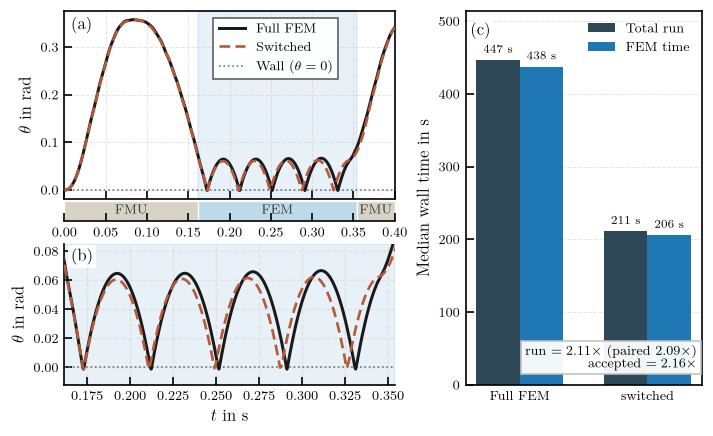

In [20]:
# --- Figure layout -----------------------------------------------------
fig = plt.figure(figsize=(FULL_WIDTH, 0.66 * FULL_WIDTH))

outer = fig.add_gridspec(
    1, 2,
    width_ratios=[1.4, 1.0],
    wspace=0.25,
    left=0.08, right=0.98, top=0.90, bottom=0.10,
)

left = outer[0, 0].subgridspec(
    4, 1,
    height_ratios=[3.2, 0.35, 0.32, 2.4],
    hspace=0.02,
)

ax_traj    = fig.add_subplot(left[0, 0])
ax_mode    = fig.add_subplot(left[1, 0], sharex=ax_traj)
ax_spacer  = fig.add_subplot(left[2, 0])
ax_contact = fig.add_subplot(left[3, 0])

ax_spacer.axis("off")

ax_time = fig.add_subplot(outer[0, 1])


# --- (a) Full-horizon trajectory ---------------------------------------
ax_traj.axvspan(*contact_window, color=MODEL_COLORS["FEM"], alpha=0.10, zorder=0)
ax_traj.plot(full["t"],     full["theta"],     label="Full FEM", **FULL_FEM_STYLE)
ax_traj.plot(switched["t"], switched["theta"], label="Switched", **SWITCHED_STYLE)
ax_traj.axhline(0, label=r"Wall ($\theta = 0$)", **WALL_STYLE)
ax_traj.set_xlim(T0, T_END)
ax_traj.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax_traj.grid(True, **GRID_STYLE)
ax_traj.tick_params(axis="x", labelbottom=False)
x_ticks = ax_traj.get_xticks()
ax_traj.set_xticks([])
ax_traj.legend(
    loc="upper center", bbox_to_anchor=(0.64, 1),
    ncol=1, fontsize=8, frameon=True, handlelength=2.0, columnspacing=1.4,
)

# --- Mode strip --------------------------------------------------------
for t_left, t_right, mode in switched["mode_intervals"]:
    width = max(0.0, t_right - t_left)
    if width <= 0:
        continue
    ax_mode.broken_barh(
        [(t_left, width)],
        (0, 1),
        facecolors=MODE_STRIP_COLORS.get(mode, "0.75"),
        edgecolors="white", linewidth=0.8, alpha=0.95, zorder=0,
    )
    if width / T_HORIZON > 0.04:
        ax_mode.text(
            t_left + width / 2, 0.55,
            mode,
            ha="center", va="center",
            fontsize=8, color=MODE_TEXT_COLOR, fontweight="medium",
        )
ax_mode.set_ylim(0, 1)
ax_mode.set_yticks([])
ax_mode.set_xlim(T0, T_END)
ax_mode.set_xticks(x_ticks)
ax_mode.tick_params(axis="x", labelbottom=True)
ax_mode.grid(False)
for spine in ("left", "right", "top" ):
    ax_mode.spines[spine].set_visible(False)

# --- (b) Contact-window zoom ------------------------------------------
ax_contact.axvspan(*contact_window, color=MODEL_COLORS["FEM"], alpha=0.10, zorder=0)
ax_contact.plot(full["t"],     full["theta"],     **FULL_FEM_STYLE)
ax_contact.plot(switched["t"], switched["theta"], **SWITCHED_STYLE)
ax_contact.axhline(0, **WALL_STYLE)
ax_contact.set_xlim(*contact_window)
ax_contact.set_ylim(-0.012, 0.085)
ax_contact.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax_contact.set_xlabel(r"$t$ in $\mathrm{s}$")
ax_contact.grid(True, color="0.85", alpha=0.6, linewidth=0.8)
for spine in ("top", "right"):
    ax_contact.spines[spine].set_visible(False)

# --- (c) Wall-clock bars -----------------------------------------------
x = np.arange(len(timing_table))
bar_w = 0.34
bars_total = ax_time.bar(x - bar_w/2, timing_table["run_median_s"],
                         width=bar_w, color=TIMING_TOTAL_COLOR, label="Total run")
bars_fem   = ax_time.bar(x + bar_w/2, timing_table["fem_wall_median_s"],
                         width=bar_w, color=TIMING_FEM_COLOR,   label="FEM time")
ax_time.bar_label(bars_total, fmt="%.0f s", fontsize=7, padding=3)
ax_time.bar_label(bars_fem,   fmt="%.0f s", fontsize=7, padding=3)
ax_time.set_xticks(x)
ax_time.set_xticklabels(
    [c.replace("FMU/FEM ", "") for c in timing_table["Case"]],
    fontsize=8,
)
ax_time.set_ylabel(r"Median wall time in $\mathrm{s}$")
ax_time.set_ylim(0, timing_table["run_median_s"].max() * 1.15)
ax_time.grid(True, axis="y", **GRID_STYLE)
ax_time.legend(loc="upper right", fontsize=8, frameon=False)

speedup = summary.loc["FMU/FEM switched", "run_speedup"]
speedup_paired = summary.loc["FMU/FEM switched", "run_speedup_paired"]
accepted = summary.loc["FMU/FEM switched", "accepted_speedup"]
ax_time.text(
    0.98, 0.04,
    rf"run $= {speedup:.2f}\times$ (paired ${speedup_paired:.2f}\times$)"
    "\n"
    rf"accepted $= {accepted:.2f}\times$",
    transform=ax_time.transAxes, ha="right", va="bottom", fontsize=8,
    bbox=dict(facecolor="white", edgecolor="0.75", alpha=0.95, pad=2.5),
)

# --- Panel labels ------------------------------------------------------
for label, ax in [("(a)", ax_traj), ("(b)", ax_contact), ("(c)", ax_time)]:
    ax.text(0.02, 0.97, label, transform=ax.transAxes,
            ha="left", va="top", **PANEL_LABEL_STYLE)

fig.savefig(OUT_DIR / "06_performance_switching.pdf", bbox_inches="tight")
plt.show()


---------

## Interpretation Notes

Read the tables above rather than any number written into this prose - they are regenerated on every
execution, and absolute timings move with interpreter and machine state.

**What to quote.** Use `run_speedup_paired` if the drift check warned, `run_median_s` and
`run_speedup` otherwise. Both cases run `HybridAlgorithm`, so the wall-time ratio needs no
correction here.

**Where the speedup comes from.** `fem_active_sim_share` is the fraction of simulated time the FEM
model was active. Because the FEM dominates the cost, the accepted-model-time saving should come out
close to the inverse of that share, and the summary cell prints both so the gap is visible. A large
gap means the number is being driven by something other than the model choice.

**What the speedup costs.** The error table reports the deviation of the switched trajectory from
the full-FEM trajectory over the whole horizon and over the contact window, where it matters.

**What is left on the table.** The phase table shows how much model time is computed and then
discarded. Trial steps are the dominant part: on an event-free macro step, `_detect_crossings`
solves the interval, throws the result away, and Gauss-Seidel solves it again. Reusing an accepted
trial step when no crossing was found would remove that work from both cases.

**Is the wrapper the bottleneck?** Compare `delegation_median_s` against `overhead_median_s`. The
wrapper only adds `_update_output_states()` and conditional history recording per call; if that is a
small share of orchestration, the cost is in the algorithm's snapshot and event bookkeeping instead,
and the profiler is the next step:

```python
import cProfile, pstats
system, plant, models, meta = build_switched_case()
cProfile.run("system.run(T0, T_END, MACRO_DT)", "perf.prof")
pstats.Stats("perf.prof").sort_stats("cumulative").print_stats(25)
```

In [21]:
performance_summary = {
    "run_speedup": summary.loc["FMU/FEM switched", "run_speedup"],
    "run_speedup_paired": summary.loc["FMU/FEM switched", "run_speedup_paired"],
    "accepted_speedup": summary.loc["FMU/FEM switched", "accepted_speedup"],
    "full_fem_run_median_s": summary.loc["Full FEM", "run_median_s"],
    "switched_run_median_s": summary.loc["FMU/FEM switched", "run_median_s"],
    "switched_fem_active_share": summary.loc["FMU/FEM switched", "fem_active_sim_share"],
    "switched_discarded_model_share": float(discarded.loc["FMU/FEM switched"]),
    "full_fem_discarded_model_share": float(discarded.loc["Full FEM"]),
    "theta_e_inf_full": metrics_full["e_inf"],
    "theta_e_2_full": metrics_full["e_2"],
    "theta_e_inf_contact": metrics_contact["e_inf"],
    "theta_e_2_contact": metrics_contact["e_2"],
}

performance_summary

{'run_speedup': np.float64(2.1138486546772697),
 'run_speedup_paired': np.float64(2.0921472501924647),
 'accepted_speedup': np.float64(2.155073568241528),
 'full_fem_run_median_s': np.float64(446.89386890000003),
 'switched_run_median_s': np.float64(211.41242440000002),
 'switched_fem_active_share': np.float64(0.48031250000000036),
 'switched_discarded_model_share': 0.5146810384610685,
 'full_fem_discarded_model_share': 0.5061162273182838,
 'theta_e_inf_full': np.float64(0.02898652045019153),
 'theta_e_2_full': np.float64(0.007925611820152084),
 'theta_e_inf_contact': np.float64(0.02898652045019153),
 'theta_e_2_contact': np.float64(0.01077638305954171)}